In [1]:
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"XPU Available: {torch.xpu.is_available()}")

if torch.xpu.is_available():
    print(f"Current Device: {torch.xpu.get_device_name(0)}")
    # Test a small tensor on the Arc GPU
    x = torch.randn(3, 3).to("xpu")
    print("Success! Tensor moved to Intel Arc.")

PyTorch Version: 2.11.0+xpu
XPU Available: True
Current Device: Intel(R) Graphics [0x64a0]
Success! Tensor moved to Intel Arc.


In [3]:
import os
from pathlib import Path

def consolidate_dataset(dataset_path, new_class_id=0):
    # Process train, valid, and test sets
    for split in ['train', 'valid', 'test']:
        label_dir = Path(dataset_path) / split / 'labels'
        if not label_dir.exists(): continue
        
        for label_file in label_dir.glob('*.txt'):
            with open(label_file, 'r') as f:
                lines = f.readlines()
            
            # Rewrite every line to start with class 0
            consolidated_lines = []
            for line in lines:
                parts = line.split()
                if parts:
                    parts[0] = str(new_class_id)
                    consolidated_lines.append(" ".join(parts) + "\n")
            
            with open(label_file, 'w') as f:
                f.writelines(consolidated_lines)

consolidate_dataset('insectdata')

In [ ]:
import wandb
from ultralytics import YOLOWorld


# 1. Initialize W&B project
wandb.init(project="phobia-detector-yoloworld", job_type="training")

# 2. Load the YOLO-World model
# Using 'v2' models is highly recommended for custom training
model = YOLOWorld('yolov8s-worldv2.pt')

# 3. Fine-tune
# The 'data' parameter points to the data.yaml file provided by Roboflow



model.train(
    data='insectdata/data.yaml',
    epochs=50,
    patience=5,
    amp=False,
    imgsz=640,
    batch=16,
    device=torch.device('xpu'),      
    project="phobia-detector",
    name="insect_finetune",
    
    # --- AUGMENTATION STRATEGY ---
    # These prevent the model from memorizing specific images
    mosaic=1.0,        # ON: Combines 4 images into one (excellent for small insects)
    mixup=0.1,         # ON: Blends two images (forces model to see through "noise")
    fliplr=0.5,        # 50% chance to flip horizontally
    flipud=0.2,        # 20% chance to flip vertically (good for ceiling/wall bugs)
    degrees=15.0,      # Rotates image +/- 15 degrees
    scale=0.5,         # Random zoom in/out (critical for varying bug distances)
    hsv_h=0.015,       # Slight color shifts (wasp yellow vs. golden hour yellow)
    hsv_s=0.7,         # Saturation shifts
    hsv_v=0.4,         # Value/Brightness shifts (indoor vs. outdoor lighting)
    
    # --- REFINEMENT ---
    freeze=10,         # Freeze first 10 layers to keep "general visual knowledge"
    lr0=0.01,          # Initial learning rate
    close_mosaic=10    # Turn off mosaic for the last 10 epochs to refine sharp edges
)

# 4. Finish the W&B run
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=insectdata/data.yaml, degrees=15.0, deterministic=True, device=xpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s-worldv2.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=insect_finetune3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, pro

/home/aadit/FAI/final/Realtime-Phobia-Filter/.venv/lib/python3.12/site-packages/ultralytics/utils/loss.py:379: UserWarning: scatter_add_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  offsets.scatter_add_(0, batch_idx + 1, torch.ones_like(batch_idx))



image 1/1 /home/aadit/FAI/final/Realtime-Phobia-Filter/spider.jpg: 448x640 2 bugs, 95.9ms
Speed: 1.0ms preprocess, 95.9ms inference, 9.6ms postprocess per image at shape (1, 3, 448, 640)


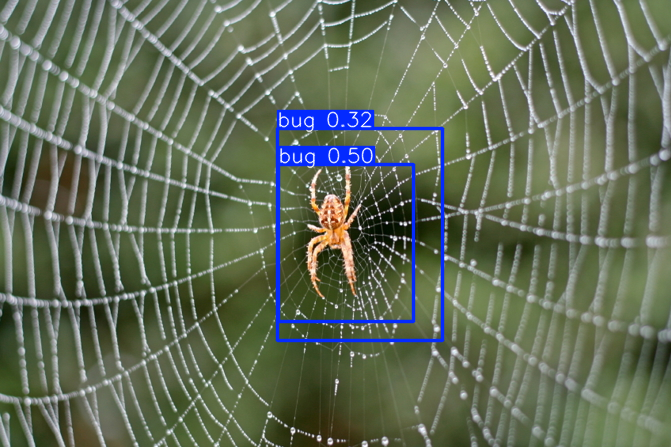

In [2]:
from ultralytics import YOLOWorld
model = YOLOWorld('runs/detect/phobia-detector/insect_finetune/weights/best.pt')
model.set_classes(["bug"])
results = model.predict("spider.jpg")
results[0].show()

In [7]:
import cv2
import collections

cap = cv2.VideoCapture('yellowriceborer.mp4')
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS)) 

out = cv2.VideoWriter('riceborerblur.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

# --- PERSISTENCE SETTINGS ---
# Stores the last known box for each insect ID {id: [x1, y1, x2, y2]}
last_known_boxes = {} 
# How many frames to keep blurring after the bug is lost (e.g., 5 frames)
persistence_limit = 5 
# Track how many frames ago we saw each ID
frames_since_seen = collections.defaultdict(int) 

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # 2. Run Tracking (Persist=True is key)
    # Lowering conf slightly to 0.2 since we are using a tracker to filter noise
    results = model.track(frame, persist=True, conf=0.2, imgsz=640, device='cpu')

    current_frame_ids = []

    for r in results:
        if r.boxes is not None and r.boxes.id is not None:
            boxes = r.boxes.xyxy.cpu().numpy()
            ids = r.boxes.id.cpu().numpy().astype(int)

            for box, obj_id in zip(boxes, ids):
                last_known_boxes[obj_id] = box
                frames_since_seen[obj_id] = 0
                current_frame_ids.append(obj_id)

    # 3. Process All Active Blurs (Actual detections + Persistent "ghost" boxes)
    for obj_id in list(last_known_boxes.keys()):
        if frames_since_seen[obj_id] < persistence_limit:
            x1, y1, x2, y2 = map(int, last_known_boxes[obj_id])
            
            # --- IMPROVEMENT: PADDING ---
            # Make the blur 20% larger than the box to catch legs/motion
            pad = 20
            x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
            x2, y2 = min(w, x2 + pad), min(h, y2 + pad)

            # Apply Blur
            roi = frame[y1:y2, x1:x2]
            if roi.size > 0:
                frame[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (99, 99), 0)
            
            # Increment the counter if we didn't see it this frame
            if obj_id not in current_frame_ids:
                frames_since_seen[obj_id] += 1
        else:
            # Clean up old data
            del last_known_boxes[obj_id]
            del frames_since_seen[obj_id]

    out.write(frame)

cap.release()
out.release()
print("Video saved as robust_blur.mp4")


0: 640x384 (no detections), 160.9ms
Speed: 7.1ms preprocess, 160.9ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 134.9ms
Speed: 20.7ms preprocess, 134.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 97.8ms
Speed: 1.1ms preprocess, 97.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 129.8ms
Speed: 2.6ms preprocess, 129.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 151.2ms
Speed: 1.4ms preprocess, 151.2ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 115.8ms
Speed: 4.6ms preprocess, 115.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 125.5ms
Speed: 1.1ms preprocess, 125.5ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 125.3ms
Speed: 1.2ms prepro